In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n
import glob
import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
import function_sampling_Thermal_forcing_files as fn
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import linregress
from collections import Counter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.colors as mcolors
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalarsHelene'
mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path
pth_imip6hack= mnt_pth + 'ismip6_hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6_hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6_hackathon/ComputedScalarsHelene/'
 
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
removeFileID = [] # specify models to remove
 
metadata_file = 'Metadata_icefront.txt'
df_info = pd.read_csv(metadata_file)          
# Remove rows where 'fileID' is in removeFileID
df_info_filtered = df_info[~df_info['fileID'].isin(removeFileID)]

# # Assign the filtered DataFrame back to df_info
df_info = df_info_filtered

renamer = {}
renamer['DOE_MALI_4km']='DOE_MALI_1'
renamer['DOE_MALI_8km_Ant95']='DOE_MALI_2'
renamer['DOE_MALI_8km_AntMean']='DOE_MALI_3'

### Beware the order of Models in the panda data frames is not the same due to the chaneg in BMB cum with IMAU

In [2]:



df_best = pd.read_csv('tables/best_ms_method_per_model.csv')



df_dslr2100 = pd.read_csv('./tables/dslc_anom_2100.csv')
df_dslr2200 = pd.read_csv('./tables/dslc_anom_2200.csv')
df_dslr2300 = pd.read_csv('./tables/dslc_anom_2300.csv')





df_cumBMB2100 = pd.read_csv('./tables/cumulative_shelfmelt_2100.csv')
df_cumBMB2200= pd.read_csv('./tables/cumulative_shelfmelt_2200.csv')
df_cumBMB2300 = pd.read_csv('./tables/cumulative_shelfmelt_2300.csv')




dfds = [
   df_dslr2100,
   df_dslr2200,
   df_dslr2300,

    df_cumBMB2100,
    df_cumBMB2200 ,
    df_cumBMB2300, 
  
]


for df_ms in dfds:
    df_ms['WestAntarctica'] = df_ms['region_1']
    df_ms['EastAntarctica'] = df_ms['region_2']
    df_ms['Peninsula'] = df_ms['region_3']
    df_ms['Aurora']=df_ms['sector_8']
    df_ms ['Wilkes']=df_ms['sector_7']
    
regions = ['AIS',
 'Amundsen',
 'Ross',
 'FilchnerRonne',
           'Aurora',
           'Wilkes'
    ]
regions_keys ={}
regions_keys['AIS'] = ['']

regions_keys['Amundsen']=['_sector_4']
regions_keys['Ross']=['_sector_2','_sector_6',]
regions_keys['FilchnerRonne']= ['_sector_5','_sector_11']
regions_keys['Aurora']= ['_sector_8']
regions_keys['Wilkes']= ['_sector_7']
Models = df_best.Model.values

In [3]:
dfs = [
    df_dslr2100,
   df_dslr2200,
   df_dslr2300]
regions_extra=[ 'Amundsen',
 'Ross',
 'FilchnerRonne']
for df in dfs:
    for key in regions_extra:
        y = 0
        for sectors in regions_keys[key]:
        
            y =y + df[sectors[1:]]
        df[key]=y

In [4]:

Models = df_cumBMB2300[df_cumBMB2300.Experiment == 'expAE02'].Model.values
Models

array(['IMAU_UFEMISM4', 'IMAU_UFEMISM3', 'IMAU_UFEMISM2', 'IMAU_UFEMISM1',
       'VUW_PISM2_s4', 'VUW_PISM2_s3', 'VUW_PISM2_s2', 'VUW_PISM2_s1',
       'VUW_PISM2', 'VUW_PISM1_s4', 'VUW_PISM1_s3', 'VUW_PISM1_s2',
       'VUW_PISM1_s1', 'VUW_PISM1', 'VUB_AISMPALEO', 'UTAS_ElmerIce',
       'UNN_Ua', 'ULB_fETISh-KoriBU2', 'ULB_fETISh-KoriBU1', 'UCSD_ISSM',
       'UCM_Yelmo', 'PIK_PISM', 'NORCE_CISM5-MAR364-ERA-t1',
       'NORCE_CISM5-MAR364-ERA-t1-nonlocal',
       'NORCE_CISM5-MAR364-ERA-t1-local', 'NORCE_CISM4-MAR364-JRA-t1',
       'NORCE_CISM4-MAR364-ERA-t1', 'NORCE_CISM4-MAR364-ERA-t1-nonlocal',
       'NORCE_CISM4-MAR364-ERA-t1-local', 'NORCE_CISM3-MAR364-ERA-t1',
       'NORCE_CISM3-MAR364-ERA-t1-nonlocal',
       'NORCE_CISM3-MAR364-ERA-t1-local', 'NORCE_CISM2-MAR364-ERA-t1',
       'NCAR_CISM2', 'NCAR_CISM1', 'LSCE_GRISLI', 'LSCE_GRISLI2',
       'ILTS_SICOPOLIS', 'IGE_ElmerIce', 'DOE_MALI_8km_AntMean',
       'DOE_MALI_8km_Ant95', 'DOE_MALI_4km', 'DC_ISSM'], dtype=object)

### same but with  params


In [5]:
# params_unique=df_info['Melt parameterisation'].unique()
# df_info_exp= df_info[df_info.Experiment == 'expAE02']
# unique_scatter = ['^','v','*','s','P','p']
# dic_params_scatter = {}
# marker_model = []
# for i,param in enumerate(params_unique):
#     dic_params_scatter[param]=unique_scatter[i]
# for key in df_info_exp['Melt parameterisation']:
#     marker_model.append( dic_params_scatter[key])
# # for i,Model in enumerate( df_cumBMB2300_mean.Model):
# # marker_model

In [6]:
params_unique=df_info['ice front'].unique()
df_info_exp= df_info[df_info.Experiment == 'expAE02']
unique_scatter = ['^','v','*','s','P','p']
dic_params_scatter = {}
marker_model = []
for i,param in enumerate(params_unique):
    dic_params_scatter[param]=unique_scatter[i]
for i,Model in enumerate(Models):
    if Model in ['DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean']:
        nmname = renamer[Model]
    else:
        nmname = Model
    key =df_info_exp[df_info_exp.fileID == nmname]['ice front'].values[0]
    marker_model.append( dic_params_scatter[key])
#     print('.')
    
# for key in df_info_exp['ice front']:
#     marker_model.append( dic_params_scatter[key])
# # for i,Model in enumerate( df_cumBMB2300_mean.Model):
# # marker_model

### Main figure

/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_21720/3529956973.py:46: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(xi, yi, c=colors[k], marker = marker_model[k],s=50)


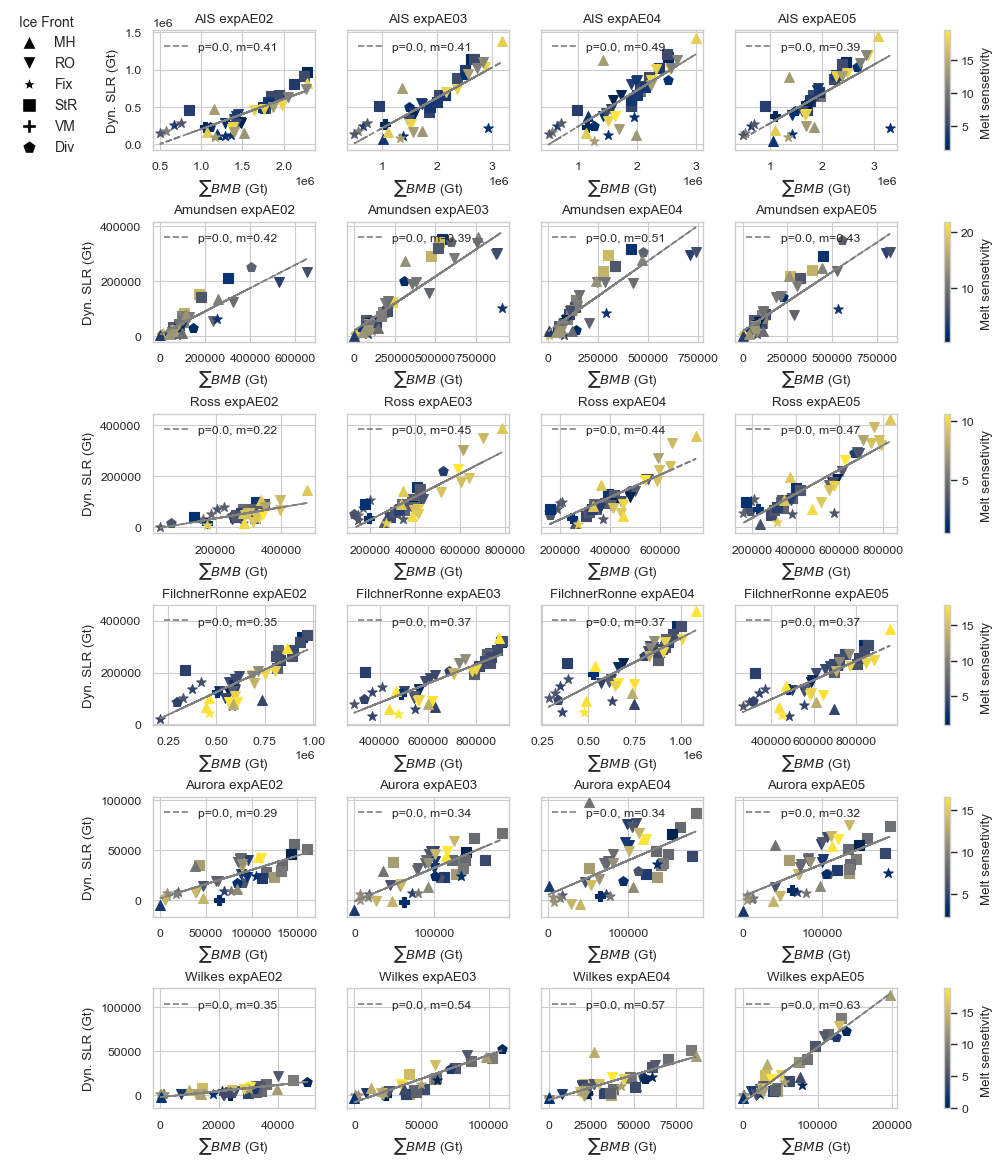

In [8]:
df_cumBMB2300_mean =  df_cumBMB2300[ df_cumBMB2300.Experiment == 'expAE02']
all_slopes = []
for i,Model in enumerate( Models):
    dm = df_cumBMB2300[ df_cumBMB2300.Model == Model]
    for j,varname in enumerate(dm.columns[3:]):
         df_cumBMB2300_mean.iloc[i,j+3] =dm[varname].values.mean()
# df_iareafl2300_change_mean
#  Create custom legend elements for parameterizations
legend_elements = [plt.Line2D([0], [0], marker=marker, color='w', label=param,
                              markerfacecolor='black', markersize=10)
                   for param, marker in dic_params_scatter.items()]

f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,14),sharey='row')
plt.subplots_adjust(wspace=0.2, hspace=0.6)
dslr = df_dslr2300
dachange = df_cumBMB2300
# dachange['Filchner_Ronne']= dachange['FilchnerRonne']


# df_iareafl2300_change['Filchner_Ronne']= df_iareafl2300_change['FilchnerRonne']
for i,region in enumerate(regions):
#     ms = df_cumBMB2300_mean[f'{region}']
#     ms = -1*df_iareagr2300_change[f'{region}']
    ms = df_best[f'melt_sensetivity_{region}']
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='cividis', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        mvuw = dachange_exp.Model != 'VUW_PISM1_s1'
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.cividis(norm(ms))
        y_dynslr = []
        for k,xi in enumerate(dachange_exp[region].values):
            Model = dachange_exp.Model[k]
        
            # Scatter plot with colors based on melt_sensetivity
            if exp == 'expAE02' and dachange_exp.Model[k] == 'VUW_PISM1_s1':
                y_dynslr.append(np.nan)
                continue
            else:
                yi = dslr_exp[dslr_exp.Model == Model][region].values[0]
                scatter = ax.scatter(xi, yi, c=colors[k], marker = marker_model[k],s=50)
                y_dynslr.append(yi)
        if exp == 'expAE02':
            x =dachange_exp[region][mvuw]
            slope, intercept, r, p, se = linregress(x, np.asarray(y_dynslr)[mvuw])
            y= slope *dachange_exp[region][mvuw] +intercept
        else:
            x = dachange_exp[region]
            slope, intercept, r, p, se = linregress(x, y_dynslr)
            y= slope *dachange_exp[region] +intercept
        all_slopes.append(slope)
        ax.plot(x,y,'--',color = 'gray', label = f'p={np.round(p,2)}, m={np.round(slope,2)}' )
        ax.set_title(f'{region} {exp}')
        ax.set_xlabel('$\sum BMB$ (Gt)')
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel('Dyn. SLR (Gt)')
        ax.legend(loc=2,frameon = False)
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'Melt sensetivity ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
f.legend(handles=legend_elements, title='Ice Front', loc='upper left', bbox_to_anchor=(0., 0.9), fontsize=10, title_fontsize=10,frameon=False)
    #     ax[i].plot(Models.index,y)  
f.savefig('figs/paper/dynslr_cum_BMB.jpeg')  
f.savefig('figs/paper/dynslr_cum_BMB.pdf')    
f.savefig('figs/paper/Fig10.jpeg')  
f.savefig('figs/paper/Fig10.pdf')   